# Copernicus Marine Comparative Spatial Mapping (Updated)

This notebook provides a detailed comparative analysis of **7 physical and biogeochemical variables** across two distinct geographic regions: **Oregon (USA)** and **Aruba (Caribbean)**.
For each library and location, we generate **6 individual maps** (total of 36 plots):
1. **Sea Water Speed & Direction (Combined Plot)** — Speed is shown as a filled contour; flow direction is overlaid as **vector arrows (quiver)** using zonal (`uo`) and meridional (`vo`) velocities.
2. **Sea Water Potential Temperature (`thetao`)** — Units: °C
3. **Sea Water Salinity (`so`)** — Units: psu
4. **pH (`ph`)** — Units: pH units
5. **Dissolved Inorganic Carbon (`dissic`)** — Units: mol/m³
6. **Total Alkalinity (`talk`)** — Units: mol/m³

### Frameworks Evaluated:
- **Cartopy (Standalone)**: Pure Matplotlib integration with Cartopy projections and features.
- **earthkit-maps**: ECMWF's high-level visualization wrapper with integrated color ramps.
- **MetPy Declarative**: Unidata's structured, object-oriented declarative plotting framework.

### Dual-Stage Smoothing Workflow:
1. **Coordinate Alignment**: BGC variables (pH, DIC, Total Alkalinity) have lower resolutions and single-point dimensions (1x2 or 3x1 grids). We align them to the higher-resolution physics grids (10x5 or 5x7 grids) using **nearest-neighbor extrapolation** to prevent NaN borders.
2. **Bilinear Spatial Interpolation**: Once coordinates are aligned, we interpolate both physics and BGC variables (including velocity vectors `uo` and `vo`) to a fine 100x100 spatial grid using a **bilinear method** to achieve high-quality, smooth contours and arrow overlays suitable for publication.


In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.plots import MapPanel, PanelContainer, FilledContourPlot, ArrowPlot
from earthkit.maps import Chart

import cmocean
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully!')


d:\antigravity\Coastcomparedfinalpaper\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


In [2]:
# Datasets definition
files = {
    'oregon_phy': 'oregon_phy2.nc',
    'oregon_bgc': 'oregon_bgc2.nc',
    'aruba_phy': 'aruba_phy.nc',
    'aruba_bgc': 'aruba_bgc.nc'
}

# Load datasets and compute the time-mean (representing annual average state over 2022-2026)
datasets = {}
for key, path in files.items():
    print(f'Loading {path}...')
    ds = xr.open_dataset(path)
    # Select surface level (depth: 0.494m)
    ds_surf = ds.isel(depth=0)
    # Compute annual time mean
    datasets[key] = ds_surf.mean(dim='time')
    # Store metadata
    datasets[key + '_years'] = f"{ds.time.min().dt.year.item()} - {ds.time.max().dt.year.item()}"
    datasets[key + '_source'] = ds.attrs.get('credit', 'Copernicus Marine Service (Mercator Ocean)')
    ds.close()

print('Datasets successfully loaded and time-averaged.')


Loading oregon_phy2.nc...
Loading oregon_bgc2.nc...
Loading aruba_phy.nc...
Loading aruba_bgc.nc...
Datasets successfully loaded and time-averaged.


In [3]:
def process_and_interpolate(region='oregon'):
    phy_ds = datasets[f'{region}_phy']
    bgc_ds = datasets[f'{region}_bgc']
    
    # 1. Nearest extrapolate BGC variables to physics grid to handle low-resolution / single-dimension points
    bgc_aligned = bgc_ds.interp(
        latitude=phy_ds.latitude, 
        longitude=phy_ds.longitude, 
        method='nearest', 
        kwargs={'fill_value': 'extrapolate'}
    )
    
    # Get scalar float bounds
    lat_min, lat_max = float(phy_ds.latitude.min()), float(phy_ds.latitude.max())
    lon_min, lon_max = float(phy_ds.longitude.min()), float(phy_ds.longitude.max())
    
    # 2. Define a fine grid spanning the physics extent
    fine_lat = np.linspace(lat_min, lat_max, 100)
    fine_lon = np.linspace(lon_min, lon_max, 100)
    
    # 3. Interpolate both to the fine grid using linear interpolation
    phy_smooth = phy_ds.interp(latitude=fine_lat, longitude=fine_lon, method='linear')
    bgc_smooth = bgc_aligned.interp(latitude=fine_lat, longitude=fine_lon, method='linear')
    
    return phy_smooth, bgc_smooth

# Precompute smoothed datasets for Oregon and Aruba
oregon_phy_smooth, oregon_bgc_smooth = process_and_interpolate('oregon')
aruba_phy_smooth, aruba_bgc_smooth = process_and_interpolate('aruba')
print('Data interpolation completed successfully.')


Data interpolation completed successfully.


In [4]:
# Metadata for the 6 plotted maps
var_metadata = {
    'thetao': {
        'name': 'Sea Water Potential Temperature',
        'units': '°C',
        'metpy_units': 'degC',
        'cmap': 'cmo.thermal',
        'is_bgc': False
    },
    'so': {
        'name': 'Sea Water Salinity',
        'units': 'psu',
        'metpy_units': 'dimensionless',
        'cmap': 'cmo.haline',
        'is_bgc': False
    },
    'speed': {
        'name': 'Sea Water Speed & Direction',
        'units': 'm/s',
        'metpy_units': 'm/s',
        'cmap': 'cmo.speed',
        'is_bgc': False
    },
    'ph': {
        'name': 'pH',
        'units': 'pH units',
        'metpy_units': 'dimensionless',
        'cmap': 'cmo.deep',
        'is_bgc': True
    },
    'dissic': {
        'name': 'Dissolved Inorganic Carbon',
        'units': 'mol/m³',
        'metpy_units': 'mole/m**3',
        'cmap': 'cmo.dense',
        'is_bgc': True
    },
    'talk': {
        'name': 'Total Alkalinity',
        'units': 'mol/m³',
        'metpy_units': 'mole/m**3',
        'cmap': 'cmo.amp',
        'is_bgc': True
    }
}
print('Metadata configured.')

Metadata configured.


In [5]:
def plot_cartopy(da, var_key, metadata, location_name, years, source, uo=None, vo=None):
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Geographic features
    ax.add_feature(cfeature.LAND, facecolor='#f5f5f5', edgecolor='#888888', zorder=2)
    ax.add_feature(cfeature.COASTLINE, edgecolor='#444444', linewidth=1.2, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='#888888', zorder=3)
    
    # Data contour
    cf = ax.contourf(da.longitude, da.latitude, da, levels=50, cmap=metadata['cmap'], transform=ccrs.PlateCarree())
    
    # Quiver overlays for combined speed and direction
    if var_key == 'speed' and uo is not None and vo is not None:
        skip = (slice(None, None, 8), slice(None, None, 8))
        X = da.longitude.values[skip[1]]
        Y = da.latitude.values[skip[0]]
        U = uo.values[skip]
        V = vo.values[skip]
        ax.quiver(X, Y, U, V, transform=ccrs.PlateCarree(), color='black', scale=None, zorder=4)
    
    # Extent & Gridlines
    lon_min, lon_max = float(da.longitude.min()), float(da.longitude.max())
    lat_min, lat_max = float(da.latitude.min()), float(da.latitude.max())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='#cccccc', zorder=1)
    gl.top_labels = False
    gl.right_labels = False
    
    # Colorbar
    cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.08, shrink=0.85)
    cbar.set_label(f"{metadata['name']} ({metadata['units']})", fontsize=10, fontweight='bold')
    
    # Titles
    plt.title(f"{location_name} - {metadata['name']}\nSource: {source} | Period: {years}\n[Cartopy Standalone]", 
              fontsize=11, fontweight='bold', pad=10)
    plt.show()

def plot_earthkit(da, var_key, metadata, location_name, years, source, uo=None, vo=None):
    chart = Chart()
    chart.coastlines(color='#444444', linewidth=1.2)
    chart.land(color='#f5f5f5')
    
    chart.contourf(da, cmap=metadata['cmap'])
    chart.gridlines(linestyle='--', color='#cccccc')
    
    # Quiver overlays for combined speed and direction
    if var_key == 'speed' and uo is not None and vo is not None:
        ax = chart.fig.axes[0]
        skip = (slice(None, None, 8), slice(None, None, 8))
        lon_mesh, lat_mesh = np.meshgrid(da.longitude, da.latitude)
        ax.quiver(lon_mesh[skip], lat_mesh[skip], uo.values[skip], vo.values[skip], 
                  transform=ccrs.PlateCarree(), color='black', zorder=4)
    
    chart.title(f"{location_name} - {metadata['name']}\nSource: {source} | Period: {years}\n[earthkit-maps]")
    chart.legend(orientation='horizontal', label=f"{metadata['name']} ({metadata['units']})")
    
    chart.show()

def plot_metpy(da, var_key, metadata, location_name, years, source, uo=None, vo=None):
    # Create dataset for MetPy
    ds_metpy = da.to_dataset(name=var_key)
    ds_metpy[var_key].attrs['units'] = metadata['metpy_units']
    ds_metpy.latitude.attrs['units'] = 'degrees_north'
    ds_metpy.longitude.attrs['units'] = 'degrees_east'
    
    plot = FilledContourPlot()
    plot.data = ds_metpy
    plot.field = var_key
    plot.colormap = metadata['cmap']
    plot.colorbar = 'horizontal'
    plot.contours = 50
    
    panel = MapPanel()
    lon_min, lon_max = float(da.longitude.min()), float(da.longitude.max())
    lat_min, lat_max = float(da.latitude.min()), float(da.latitude.max())
    panel.area = [lon_min, lon_max, lat_min, lat_max]
    panel.projection = ccrs.PlateCarree()
    
    # MetPy ArrowPlot for combined speed and direction
    if var_key == 'speed' and uo is not None and vo is not None:
        ds_metpy['uo'] = uo
        ds_metpy['uo'].attrs['units'] = 'm/s'
        ds_metpy['vo'] = vo
        ds_metpy['vo'].attrs['units'] = 'm/s'
        
        plot_arrow = ArrowPlot()
        plot_arrow.data = ds_metpy
        plot_arrow.field = ('uo', 'vo')
        plot_arrow.color = 'black'
        plot_arrow.skip = (6, 6)
        
        panel.plots = [plot, plot_arrow]
    else:
        panel.plots = [plot]
    
    panel.title = f"{location_name} - {metadata['name']}\nSource: {source} | Period: {years}\n[MetPy Declarative]"
    
    pc = PanelContainer()
    pc.size = (10, 8)
    pc.panels = [panel]
    pc.draw()
    plt.show()
print('Plotting wrappers defined.')


Plotting wrappers defined.


# Oregon Region Maps (18 Standalone Plots)


## Variable: Sea Water Speed & Direction (speed) - Oregon Region


### Cartopy Standalone Plot: Sea Water Speed & Direction (Oregon)


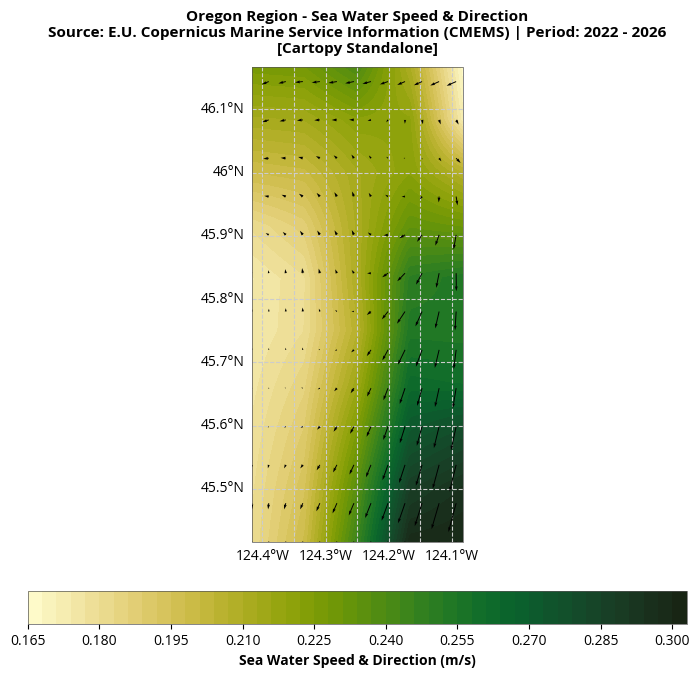

In [6]:
# Plot Sea Water Speed & Direction using Cartopy Standalone
da = oregon_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else oregon_phy_smooth.speed
years = datasets['oregon_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'speed' == 'speed' else None
plot_cartopy(da, 'speed', var_metadata['speed'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Speed & Direction (Oregon)


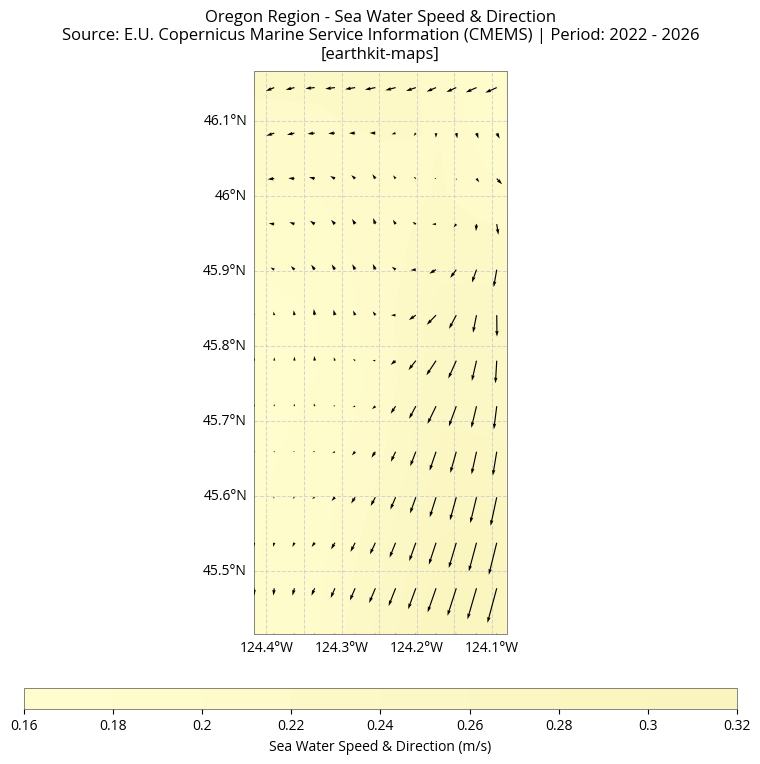

In [7]:
# Plot Sea Water Speed & Direction using earthkit-maps
da = oregon_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else oregon_phy_smooth.speed
years = datasets['oregon_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'speed' == 'speed' else None
plot_earthkit(da, 'speed', var_metadata['speed'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Speed & Direction (Oregon)


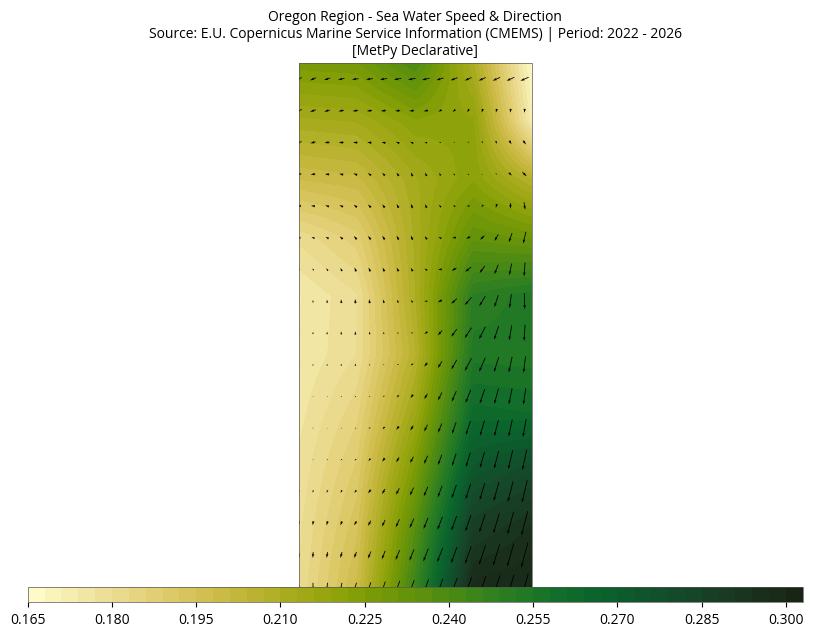

In [8]:
# Plot Sea Water Speed & Direction using MetPy Declarative
da = oregon_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else oregon_phy_smooth.speed
years = datasets['oregon_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'speed' == 'speed' else None
plot_metpy(da, 'speed', var_metadata['speed'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Sea Water Potential Temperature (thetao) - Oregon Region


### Cartopy Standalone Plot: Sea Water Potential Temperature (Oregon)


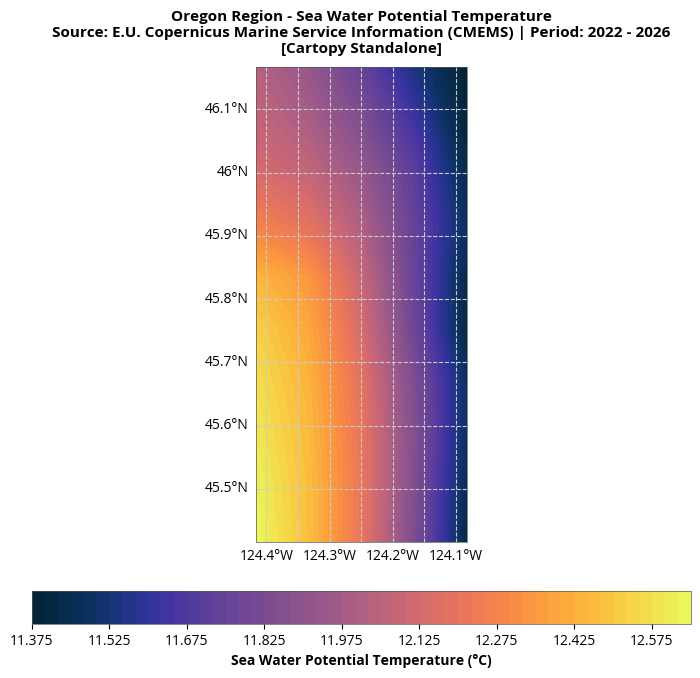

In [9]:
# Plot Sea Water Potential Temperature using Cartopy Standalone
da = oregon_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else oregon_phy_smooth.thetao
years = datasets['oregon_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'thetao' == 'speed' else None
plot_cartopy(da, 'thetao', var_metadata['thetao'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Potential Temperature (Oregon)


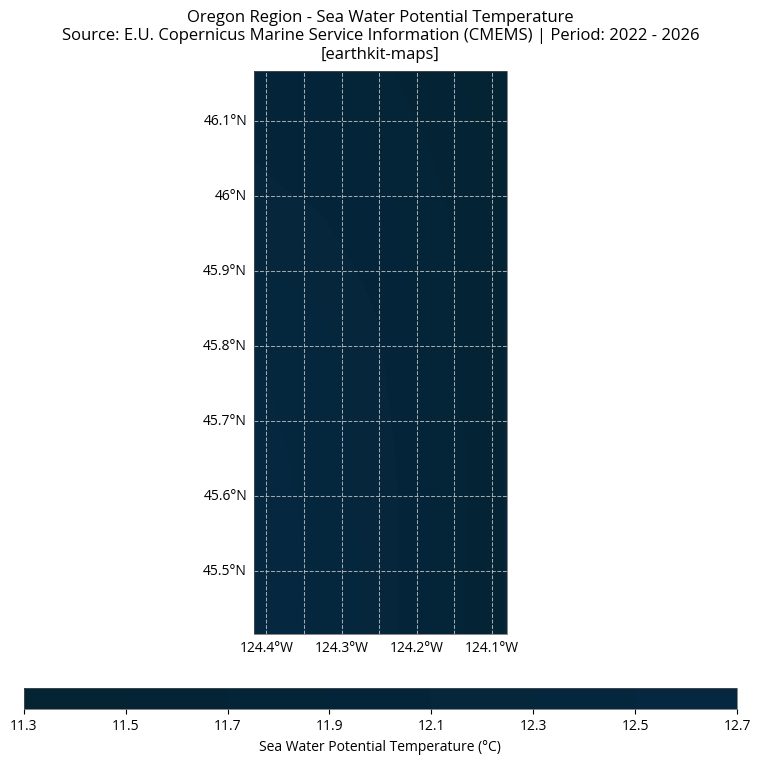

In [10]:
# Plot Sea Water Potential Temperature using earthkit-maps
da = oregon_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else oregon_phy_smooth.thetao
years = datasets['oregon_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'thetao' == 'speed' else None
plot_earthkit(da, 'thetao', var_metadata['thetao'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Potential Temperature (Oregon)


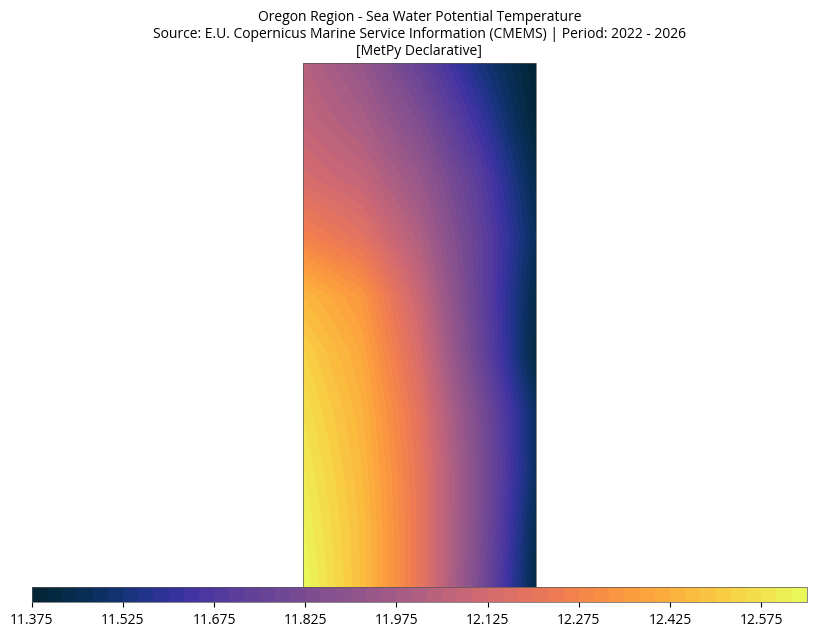

In [11]:
# Plot Sea Water Potential Temperature using MetPy Declarative
da = oregon_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else oregon_phy_smooth.thetao
years = datasets['oregon_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'thetao' == 'speed' else None
plot_metpy(da, 'thetao', var_metadata['thetao'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Sea Water Salinity (so) - Oregon Region


### Cartopy Standalone Plot: Sea Water Salinity (Oregon)


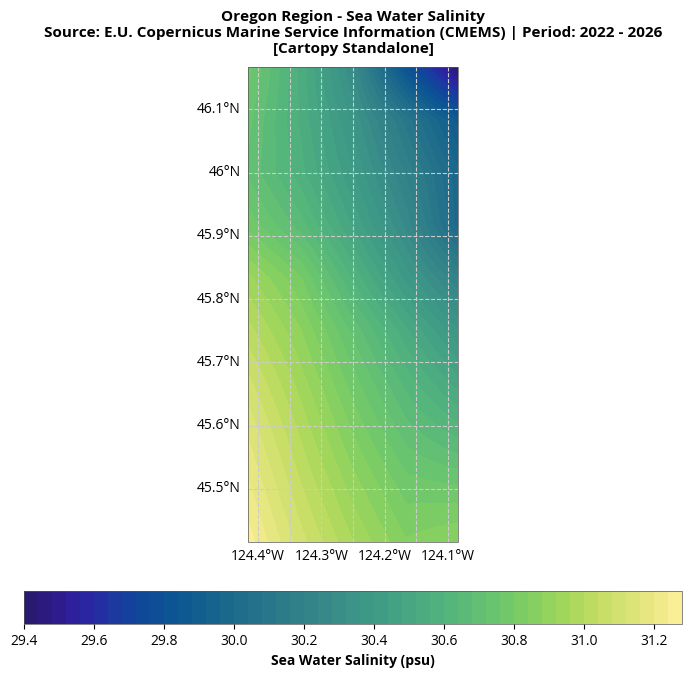

In [12]:
# Plot Sea Water Salinity using Cartopy Standalone
da = oregon_bgc_smooth.so if var_metadata['so']['is_bgc'] else oregon_phy_smooth.so
years = datasets['oregon_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'so' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'so' == 'speed' else None
plot_cartopy(da, 'so', var_metadata['so'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Salinity (Oregon)


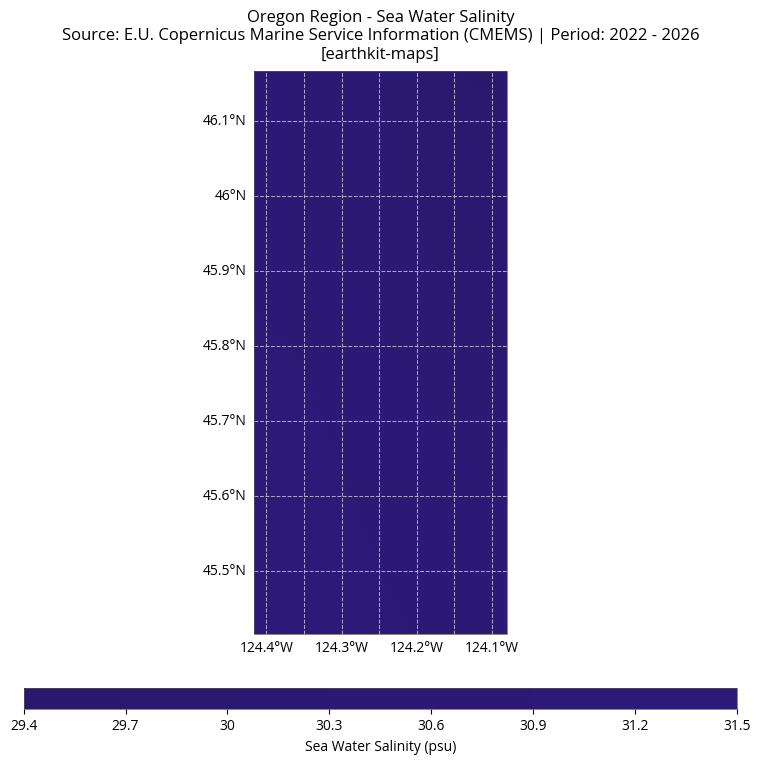

In [13]:
# Plot Sea Water Salinity using earthkit-maps
da = oregon_bgc_smooth.so if var_metadata['so']['is_bgc'] else oregon_phy_smooth.so
years = datasets['oregon_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'so' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'so' == 'speed' else None
plot_earthkit(da, 'so', var_metadata['so'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Salinity (Oregon)


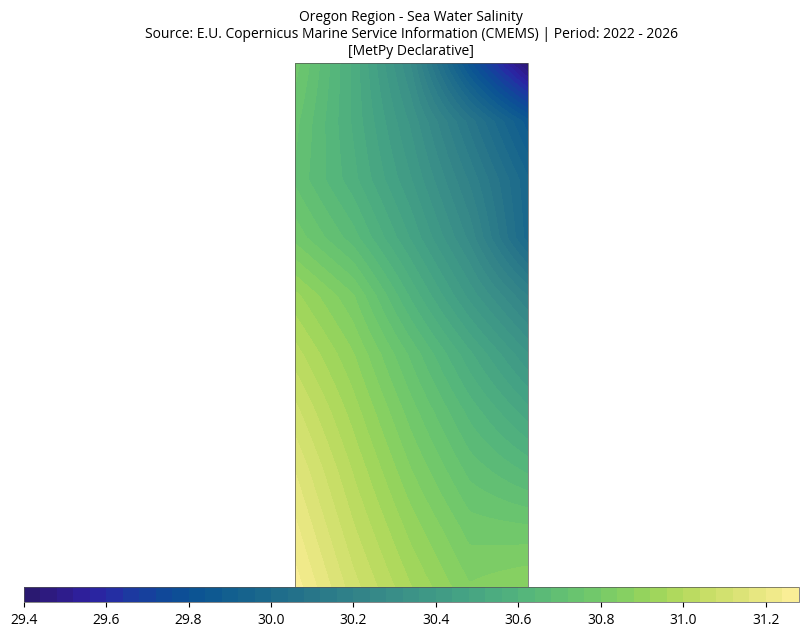

In [14]:
# Plot Sea Water Salinity using MetPy Declarative
da = oregon_bgc_smooth.so if var_metadata['so']['is_bgc'] else oregon_phy_smooth.so
years = datasets['oregon_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'so' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'so' == 'speed' else None
plot_metpy(da, 'so', var_metadata['so'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


## Variable: pH (ph) - Oregon Region


### Cartopy Standalone Plot: pH (Oregon)


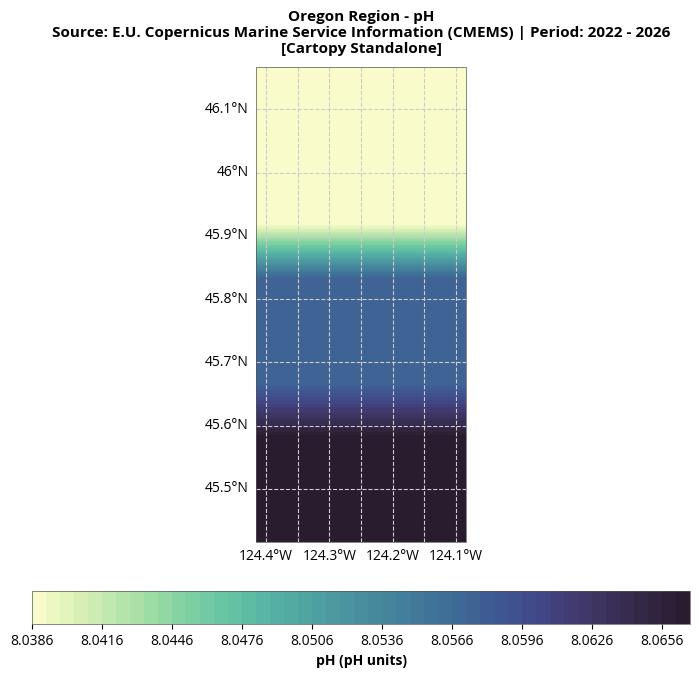

In [15]:
# Plot pH using Cartopy Standalone
da = oregon_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else oregon_phy_smooth.ph
years = datasets['oregon_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'ph' == 'speed' else None
plot_cartopy(da, 'ph', var_metadata['ph'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: pH (Oregon)


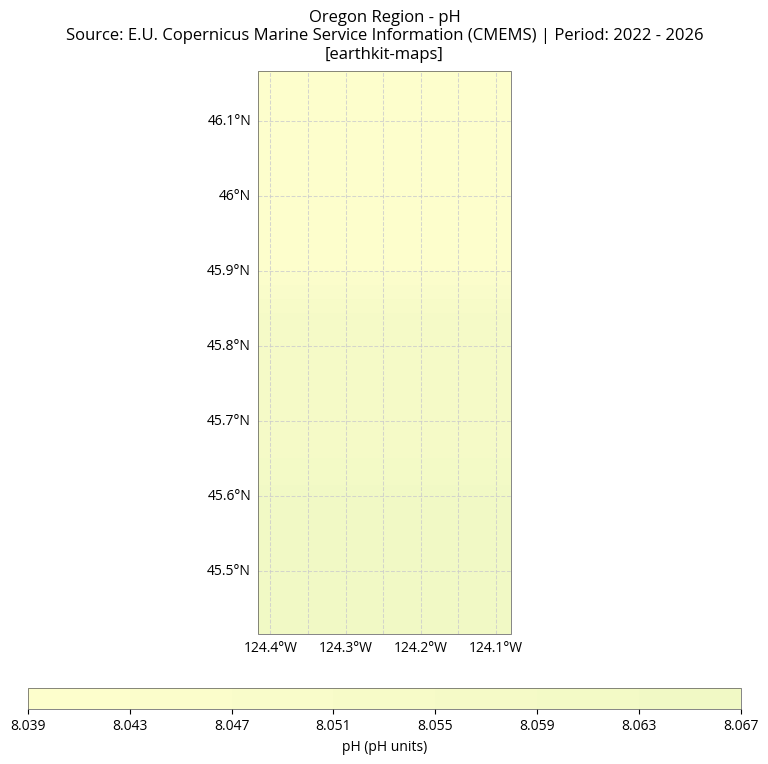

In [16]:
# Plot pH using earthkit-maps
da = oregon_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else oregon_phy_smooth.ph
years = datasets['oregon_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'ph' == 'speed' else None
plot_earthkit(da, 'ph', var_metadata['ph'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: pH (Oregon)


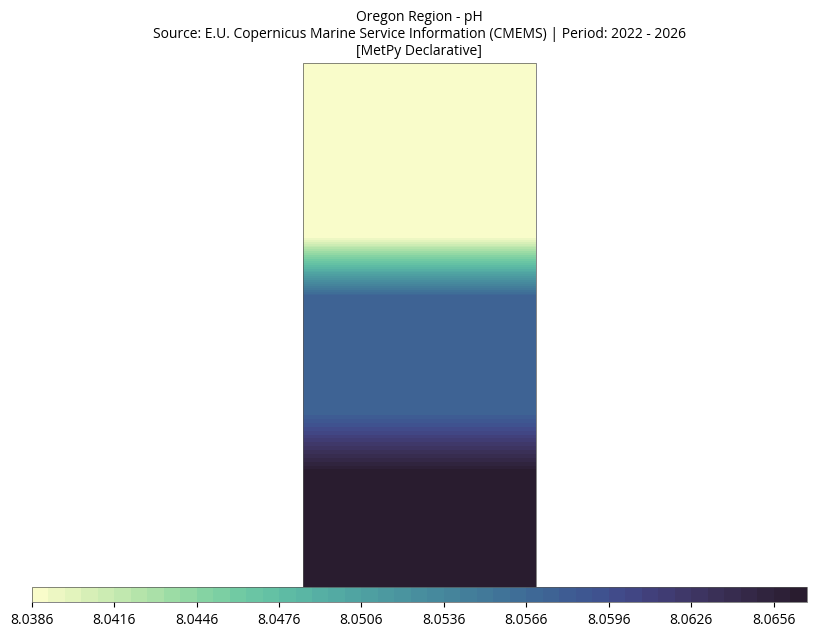

In [17]:
# Plot pH using MetPy Declarative
da = oregon_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else oregon_phy_smooth.ph
years = datasets['oregon_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'ph' == 'speed' else None
plot_metpy(da, 'ph', var_metadata['ph'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Dissolved Inorganic Carbon (dissic) - Oregon Region


### Cartopy Standalone Plot: Dissolved Inorganic Carbon (Oregon)


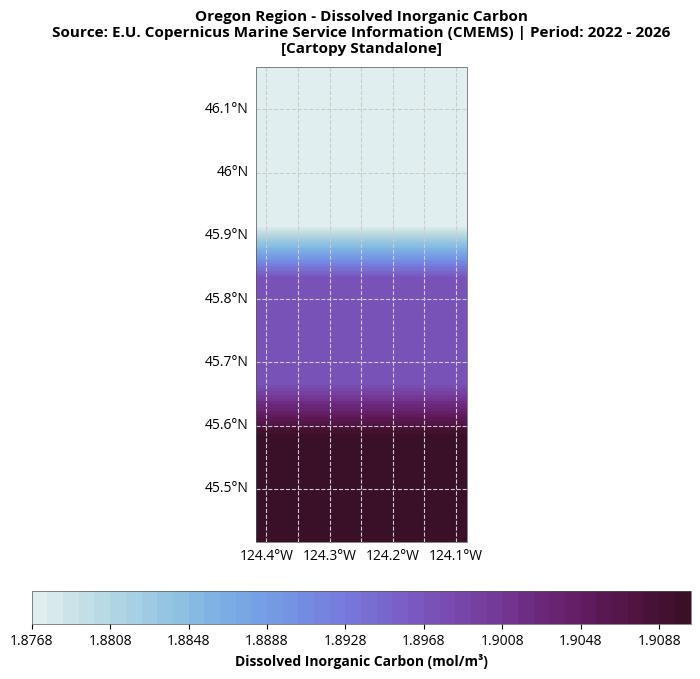

In [18]:
# Plot Dissolved Inorganic Carbon using Cartopy Standalone
da = oregon_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else oregon_phy_smooth.dissic
years = datasets['oregon_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'dissic' == 'speed' else None
plot_cartopy(da, 'dissic', var_metadata['dissic'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Dissolved Inorganic Carbon (Oregon)


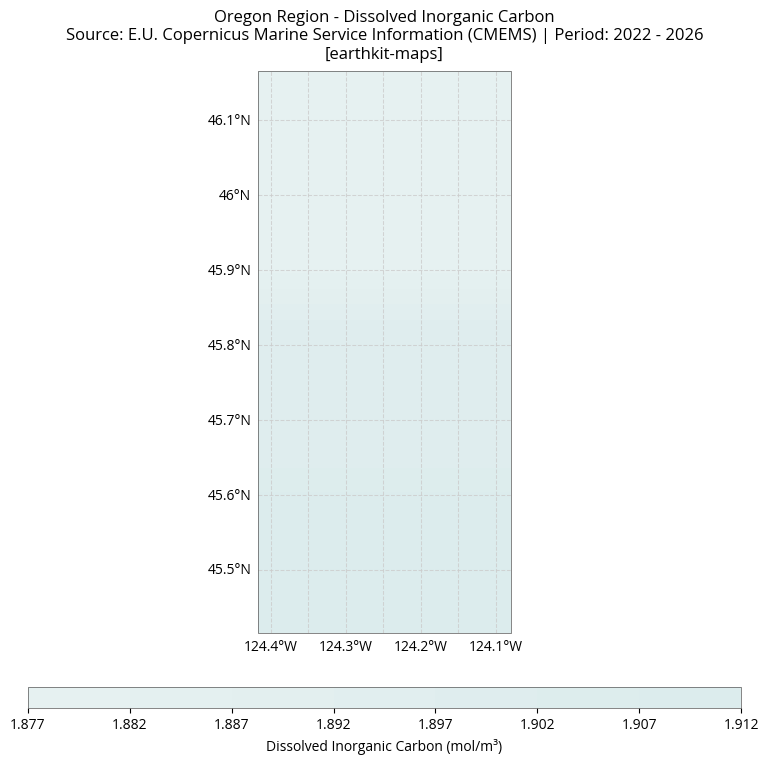

In [19]:
# Plot Dissolved Inorganic Carbon using earthkit-maps
da = oregon_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else oregon_phy_smooth.dissic
years = datasets['oregon_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'dissic' == 'speed' else None
plot_earthkit(da, 'dissic', var_metadata['dissic'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Dissolved Inorganic Carbon (Oregon)


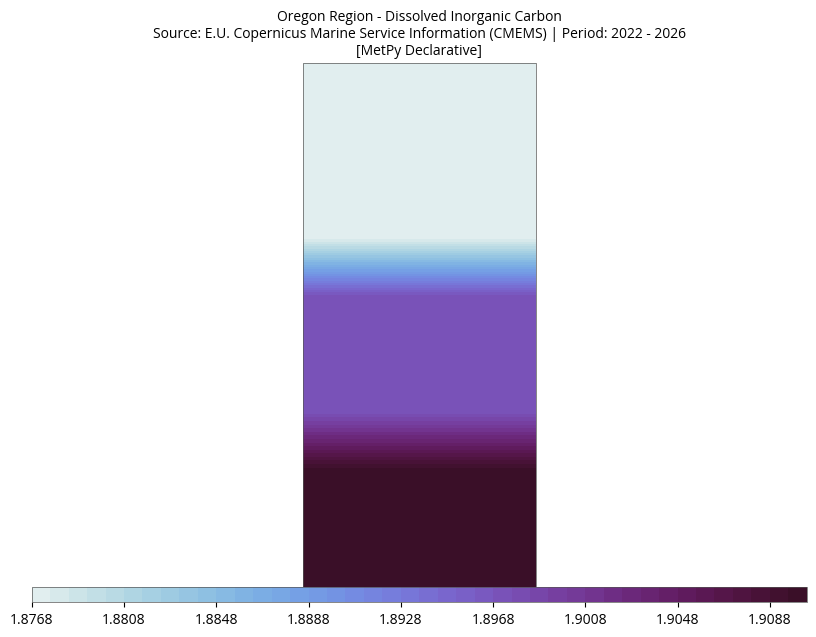

In [20]:
# Plot Dissolved Inorganic Carbon using MetPy Declarative
da = oregon_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else oregon_phy_smooth.dissic
years = datasets['oregon_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'dissic' == 'speed' else None
plot_metpy(da, 'dissic', var_metadata['dissic'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Total Alkalinity (talk) - Oregon Region


### Cartopy Standalone Plot: Total Alkalinity (Oregon)


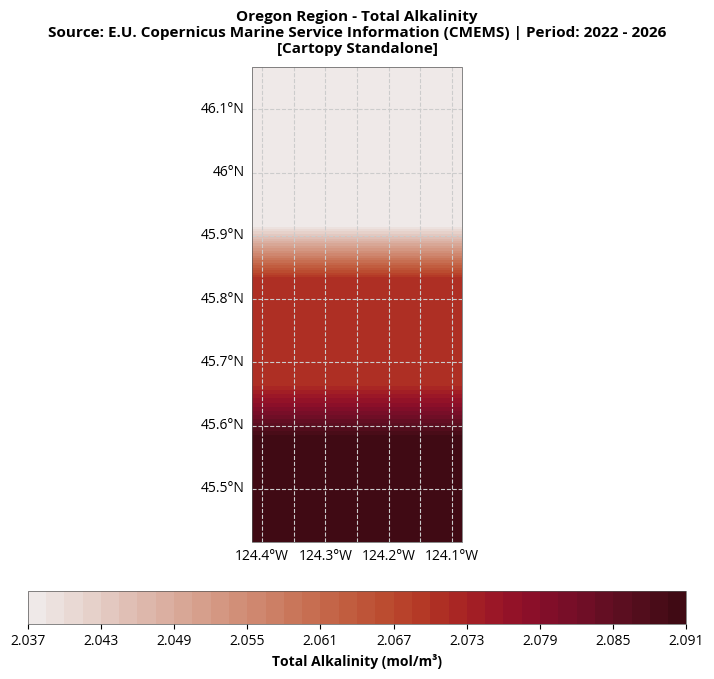

In [21]:
# Plot Total Alkalinity using Cartopy Standalone
da = oregon_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else oregon_phy_smooth.talk
years = datasets['oregon_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'talk' == 'speed' else None
plot_cartopy(da, 'talk', var_metadata['talk'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Total Alkalinity (Oregon)


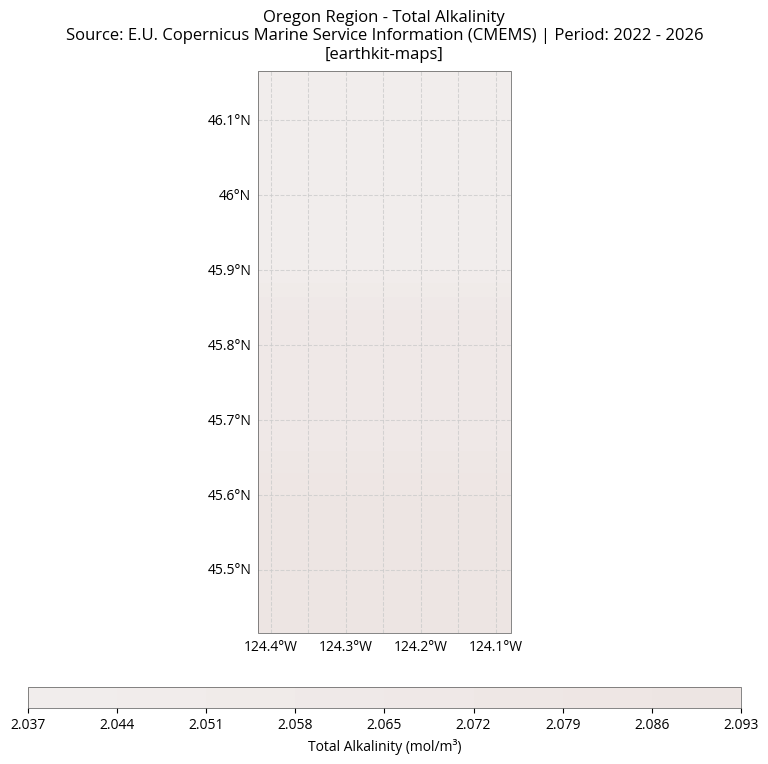

In [22]:
# Plot Total Alkalinity using earthkit-maps
da = oregon_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else oregon_phy_smooth.talk
years = datasets['oregon_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'talk' == 'speed' else None
plot_earthkit(da, 'talk', var_metadata['talk'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Total Alkalinity (Oregon)


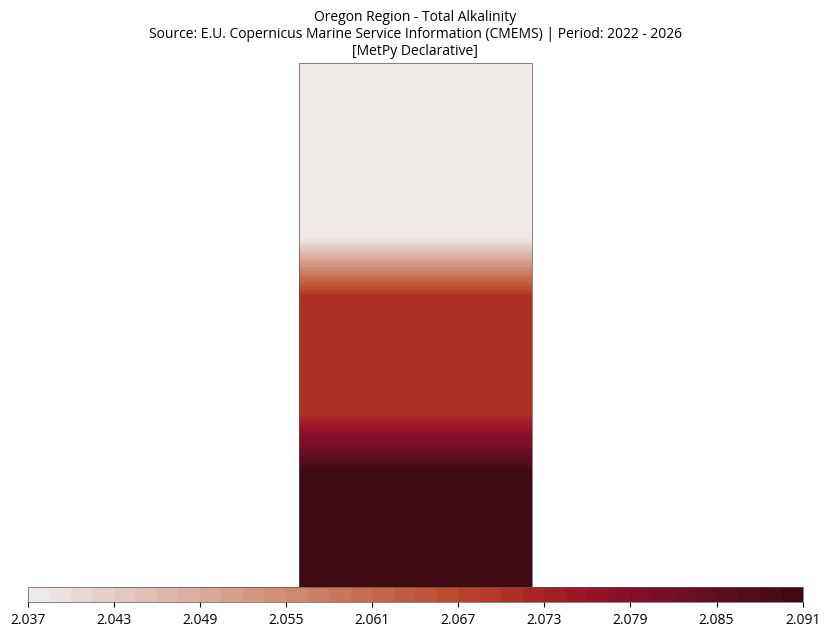

In [23]:
# Plot Total Alkalinity using MetPy Declarative
da = oregon_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else oregon_phy_smooth.talk
years = datasets['oregon_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_years']
source = datasets['oregon_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['oregon_phy_source']
uo_da = oregon_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = oregon_phy_smooth.vo if 'talk' == 'speed' else None
plot_metpy(da, 'talk', var_metadata['talk'], 'Oregon Region', years, source, uo=uo_da, vo=vo_da)


# Aruba Region Maps (18 Standalone Plots)


## Variable: Sea Water Speed & Direction (speed) - Aruba Region


### Cartopy Standalone Plot: Sea Water Speed & Direction (Aruba)


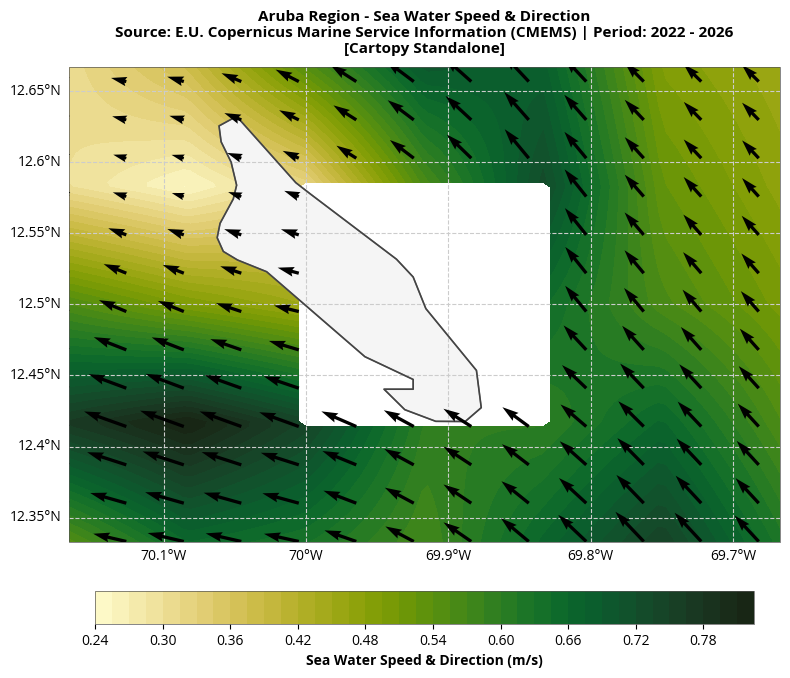

In [24]:
# Plot Sea Water Speed & Direction using Cartopy Standalone
da = aruba_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else aruba_phy_smooth.speed
years = datasets['aruba_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'speed' == 'speed' else None
plot_cartopy(da, 'speed', var_metadata['speed'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Speed & Direction (Aruba)


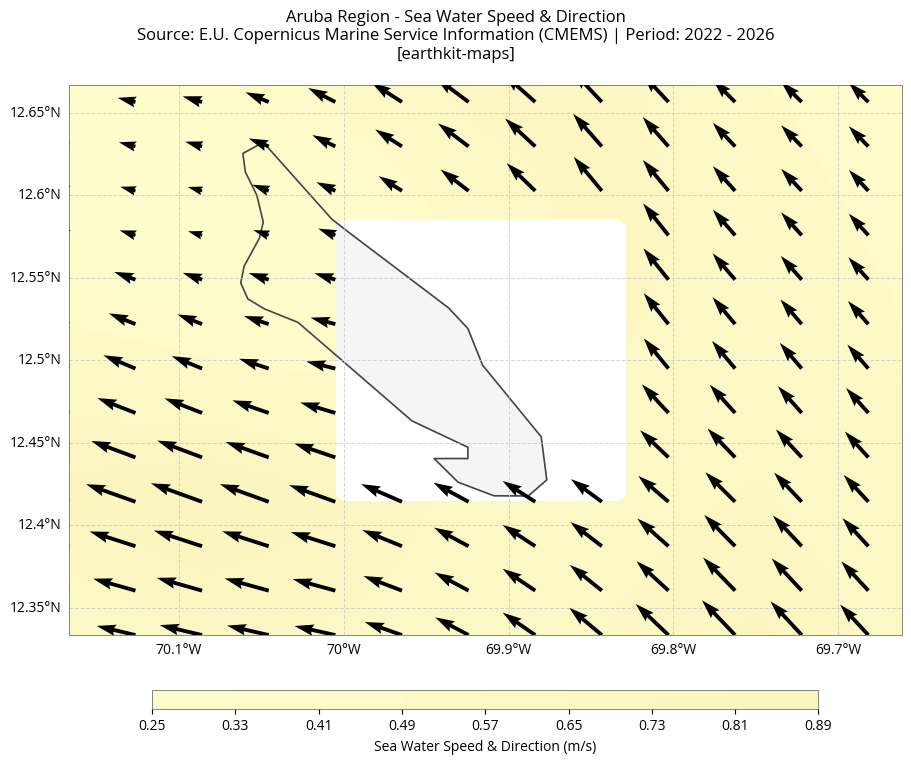

In [25]:
# Plot Sea Water Speed & Direction using earthkit-maps
da = aruba_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else aruba_phy_smooth.speed
years = datasets['aruba_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'speed' == 'speed' else None
plot_earthkit(da, 'speed', var_metadata['speed'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Speed & Direction (Aruba)


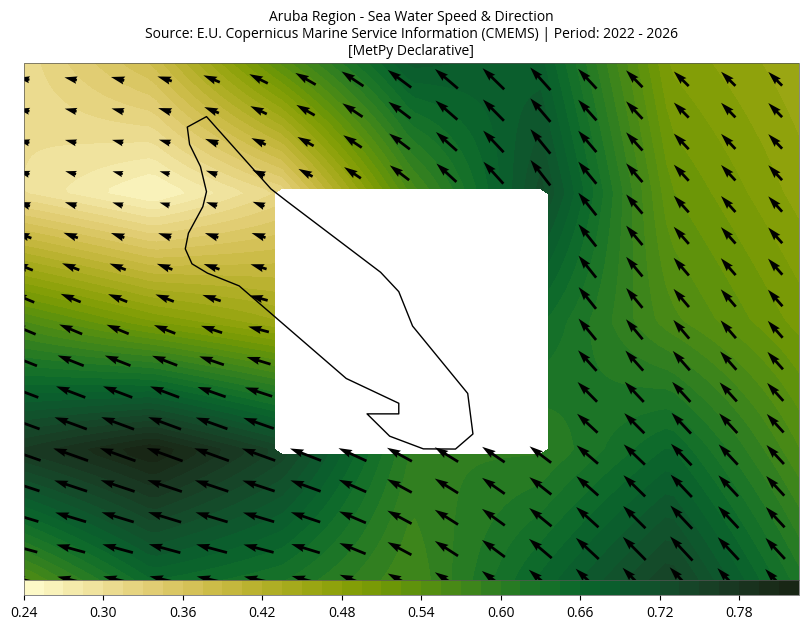

In [26]:
# Plot Sea Water Speed & Direction using MetPy Declarative
da = aruba_bgc_smooth.speed if var_metadata['speed']['is_bgc'] else aruba_phy_smooth.speed
years = datasets['aruba_bgc_years'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['speed']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'speed' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'speed' == 'speed' else None
plot_metpy(da, 'speed', var_metadata['speed'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Sea Water Potential Temperature (thetao) - Aruba Region


### Cartopy Standalone Plot: Sea Water Potential Temperature (Aruba)


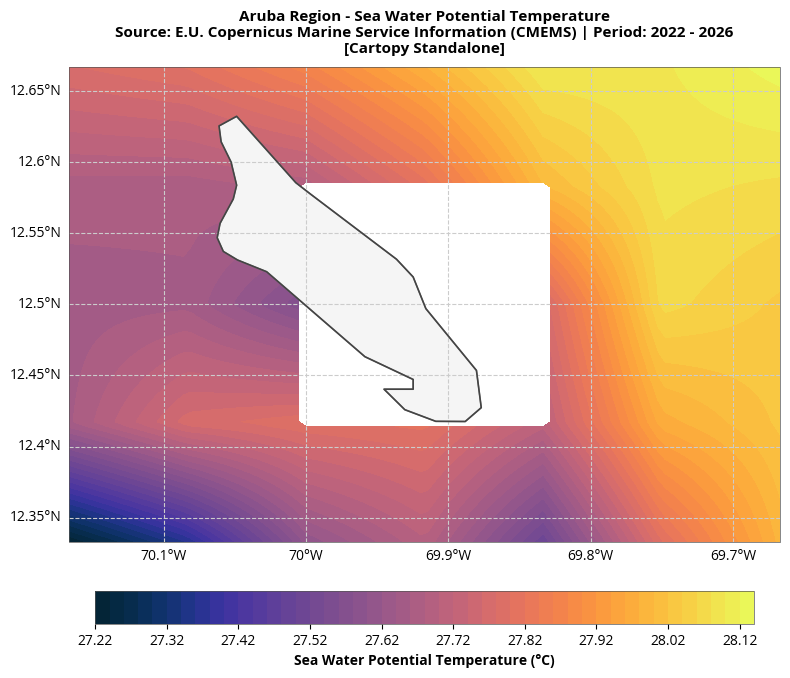

In [27]:
# Plot Sea Water Potential Temperature using Cartopy Standalone
da = aruba_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else aruba_phy_smooth.thetao
years = datasets['aruba_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'thetao' == 'speed' else None
plot_cartopy(da, 'thetao', var_metadata['thetao'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Potential Temperature (Aruba)


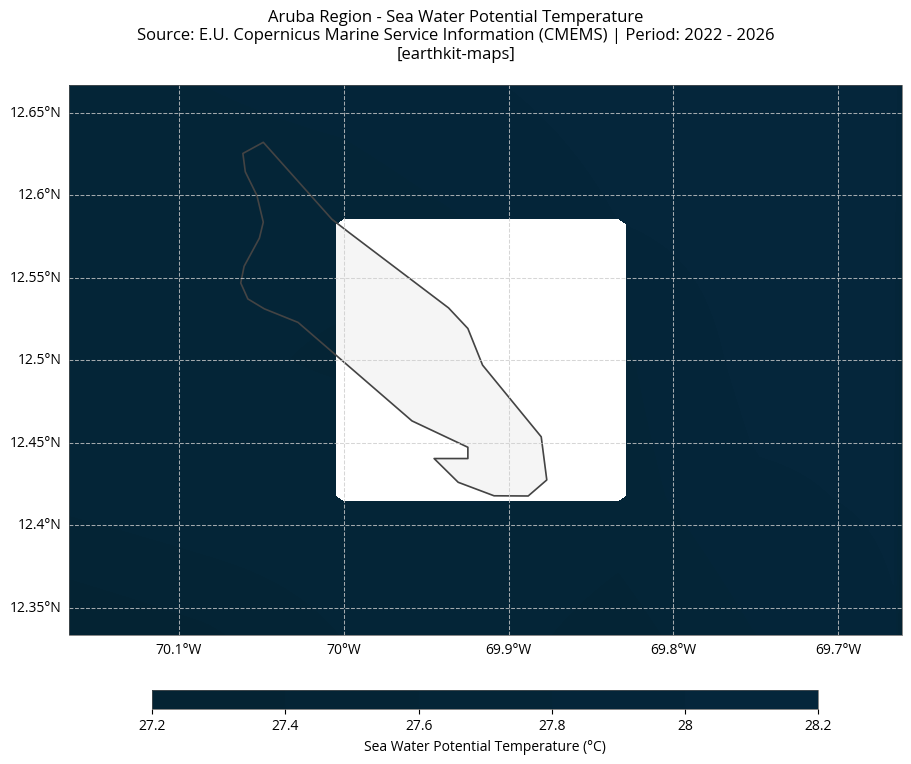

In [28]:
# Plot Sea Water Potential Temperature using earthkit-maps
da = aruba_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else aruba_phy_smooth.thetao
years = datasets['aruba_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'thetao' == 'speed' else None
plot_earthkit(da, 'thetao', var_metadata['thetao'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Potential Temperature (Aruba)


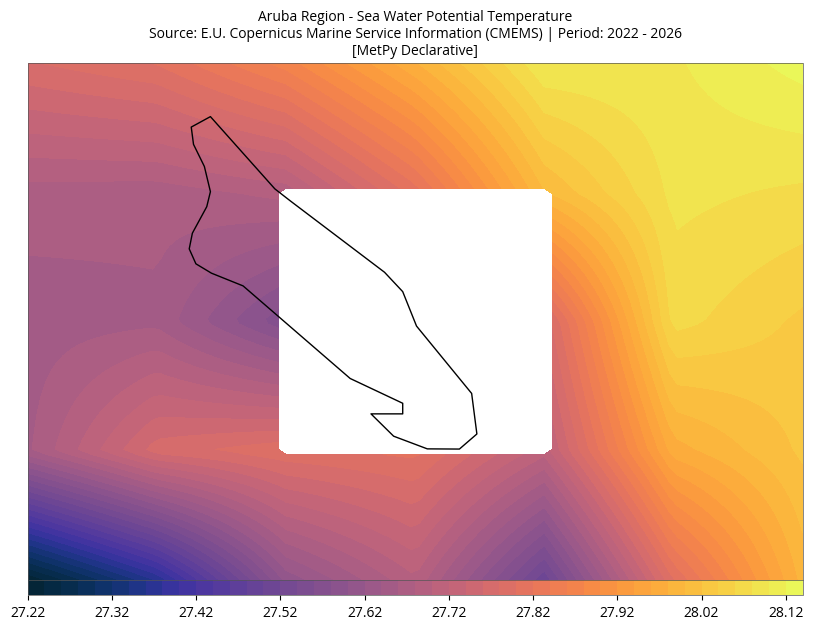

In [29]:
# Plot Sea Water Potential Temperature using MetPy Declarative
da = aruba_bgc_smooth.thetao if var_metadata['thetao']['is_bgc'] else aruba_phy_smooth.thetao
years = datasets['aruba_bgc_years'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['thetao']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'thetao' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'thetao' == 'speed' else None
plot_metpy(da, 'thetao', var_metadata['thetao'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Sea Water Salinity (so) - Aruba Region


### Cartopy Standalone Plot: Sea Water Salinity (Aruba)


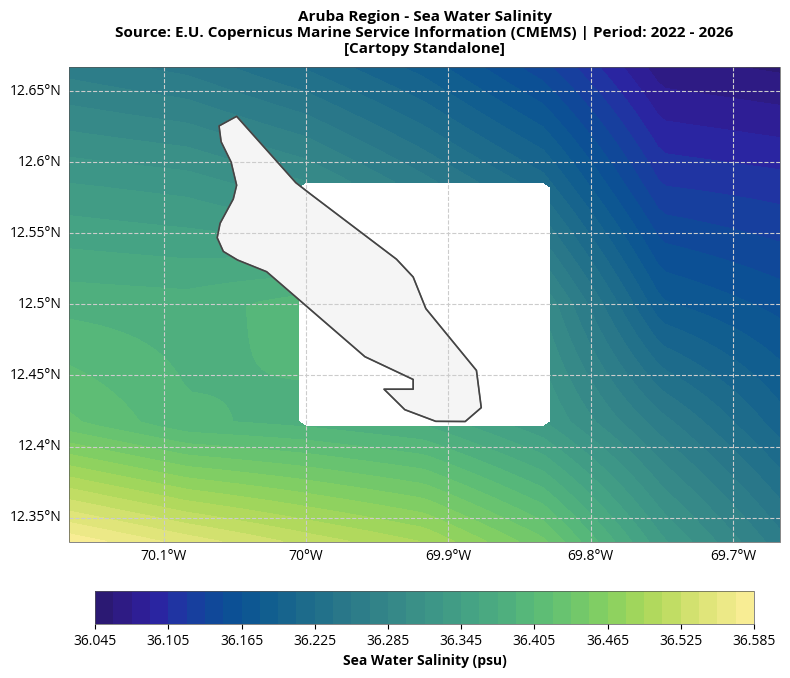

In [30]:
# Plot Sea Water Salinity using Cartopy Standalone
da = aruba_bgc_smooth.so if var_metadata['so']['is_bgc'] else aruba_phy_smooth.so
years = datasets['aruba_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'so' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'so' == 'speed' else None
plot_cartopy(da, 'so', var_metadata['so'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Sea Water Salinity (Aruba)


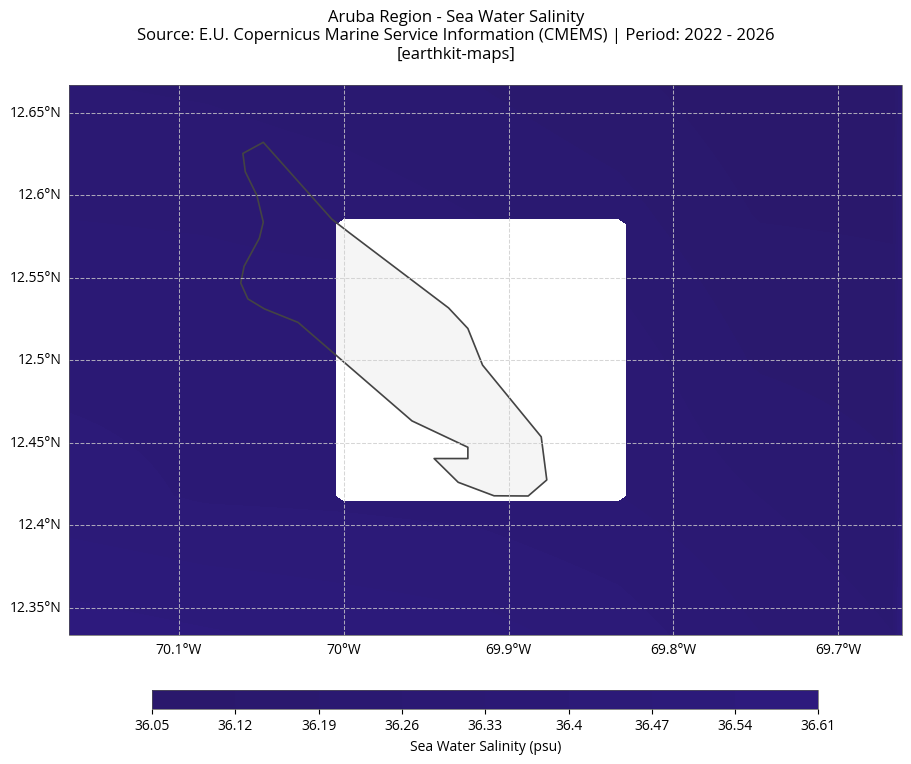

In [31]:
# Plot Sea Water Salinity using earthkit-maps
da = aruba_bgc_smooth.so if var_metadata['so']['is_bgc'] else aruba_phy_smooth.so
years = datasets['aruba_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'so' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'so' == 'speed' else None
plot_earthkit(da, 'so', var_metadata['so'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Sea Water Salinity (Aruba)


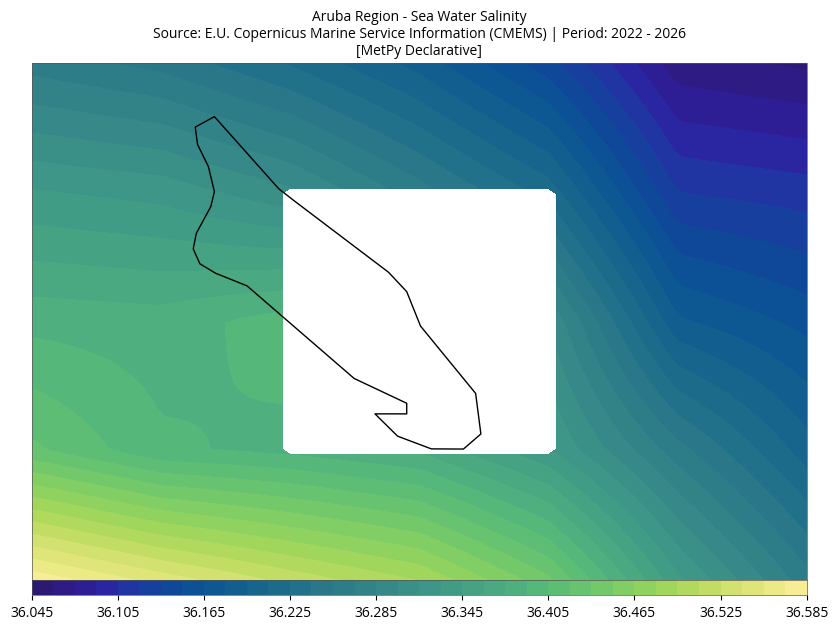

In [32]:
# Plot Sea Water Salinity using MetPy Declarative
da = aruba_bgc_smooth.so if var_metadata['so']['is_bgc'] else aruba_phy_smooth.so
years = datasets['aruba_bgc_years'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['so']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'so' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'so' == 'speed' else None
plot_metpy(da, 'so', var_metadata['so'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


## Variable: pH (ph) - Aruba Region


### Cartopy Standalone Plot: pH (Aruba)


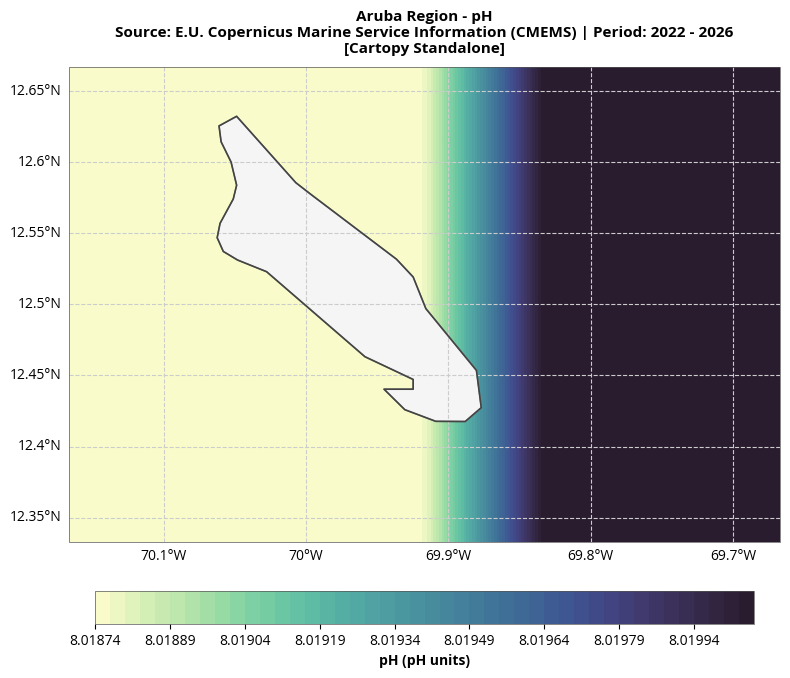

In [33]:
# Plot pH using Cartopy Standalone
da = aruba_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else aruba_phy_smooth.ph
years = datasets['aruba_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'ph' == 'speed' else None
plot_cartopy(da, 'ph', var_metadata['ph'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: pH (Aruba)


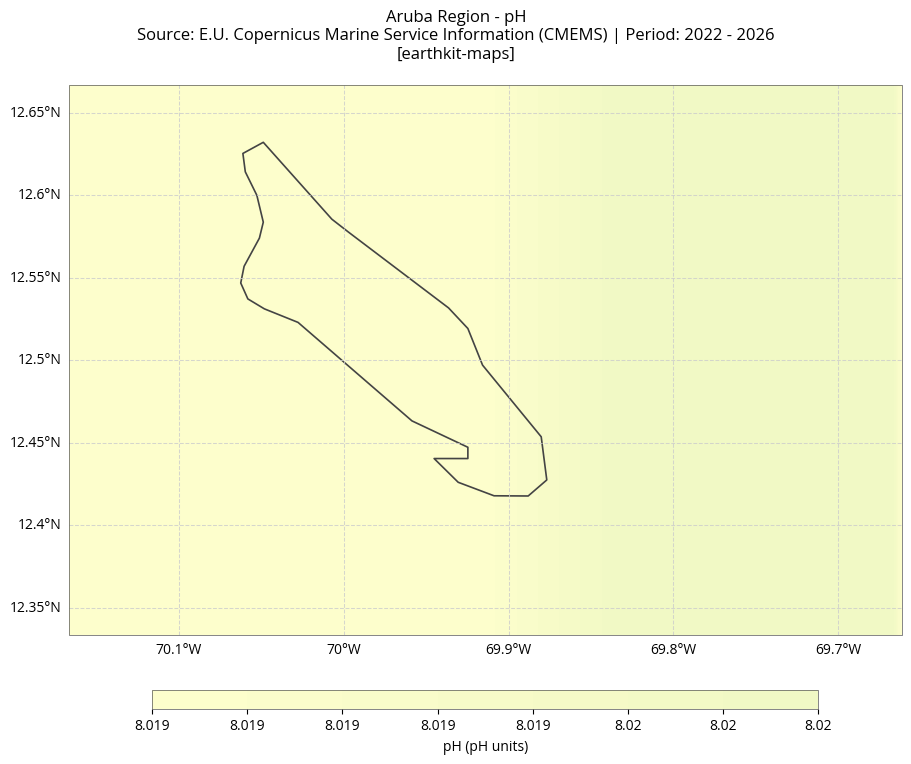

In [34]:
# Plot pH using earthkit-maps
da = aruba_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else aruba_phy_smooth.ph
years = datasets['aruba_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'ph' == 'speed' else None
plot_earthkit(da, 'ph', var_metadata['ph'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: pH (Aruba)


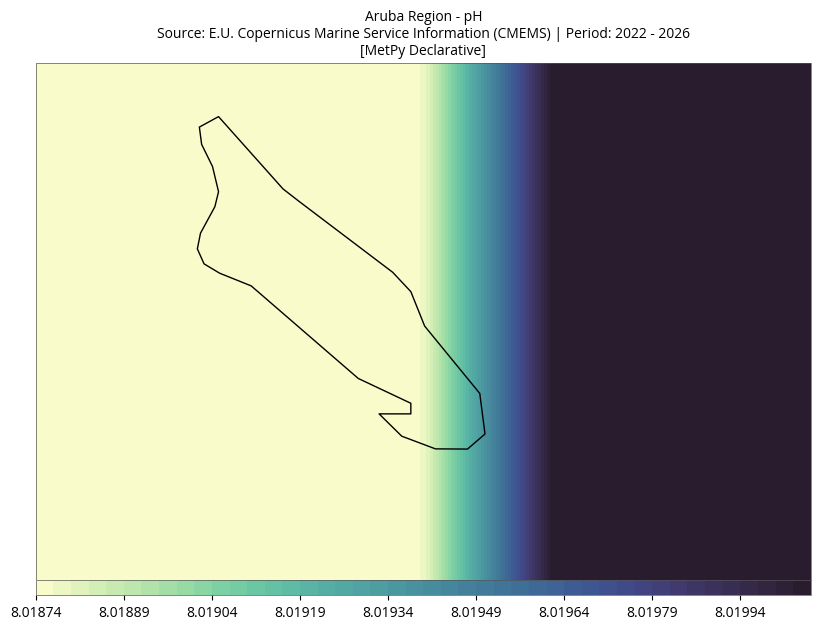

In [35]:
# Plot pH using MetPy Declarative
da = aruba_bgc_smooth.ph if var_metadata['ph']['is_bgc'] else aruba_phy_smooth.ph
years = datasets['aruba_bgc_years'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['ph']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'ph' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'ph' == 'speed' else None
plot_metpy(da, 'ph', var_metadata['ph'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Dissolved Inorganic Carbon (dissic) - Aruba Region


### Cartopy Standalone Plot: Dissolved Inorganic Carbon (Aruba)


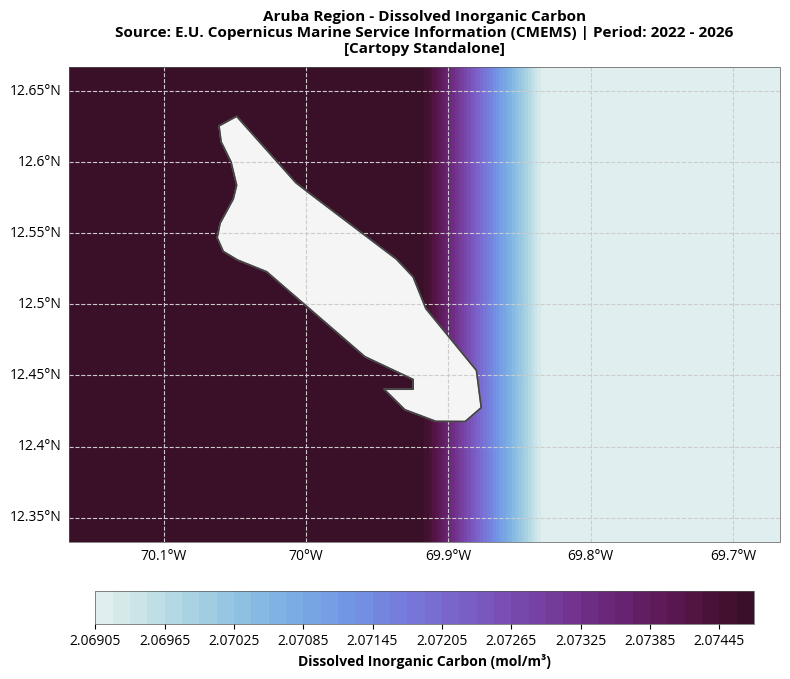

In [36]:
# Plot Dissolved Inorganic Carbon using Cartopy Standalone
da = aruba_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else aruba_phy_smooth.dissic
years = datasets['aruba_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'dissic' == 'speed' else None
plot_cartopy(da, 'dissic', var_metadata['dissic'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Dissolved Inorganic Carbon (Aruba)


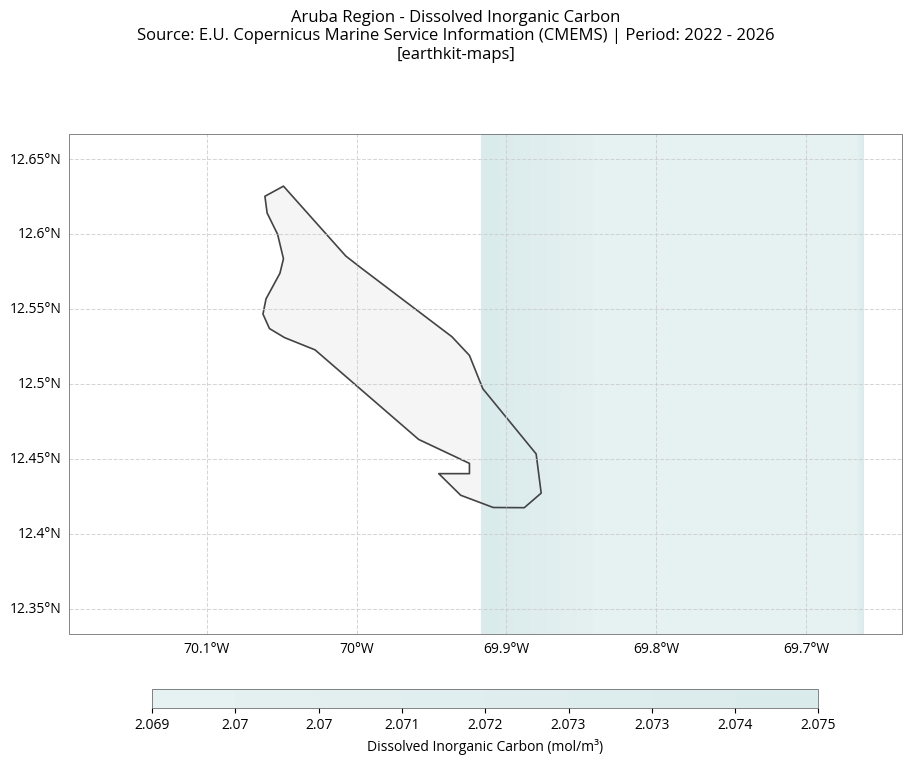

In [37]:
# Plot Dissolved Inorganic Carbon using earthkit-maps
da = aruba_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else aruba_phy_smooth.dissic
years = datasets['aruba_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'dissic' == 'speed' else None
plot_earthkit(da, 'dissic', var_metadata['dissic'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Dissolved Inorganic Carbon (Aruba)


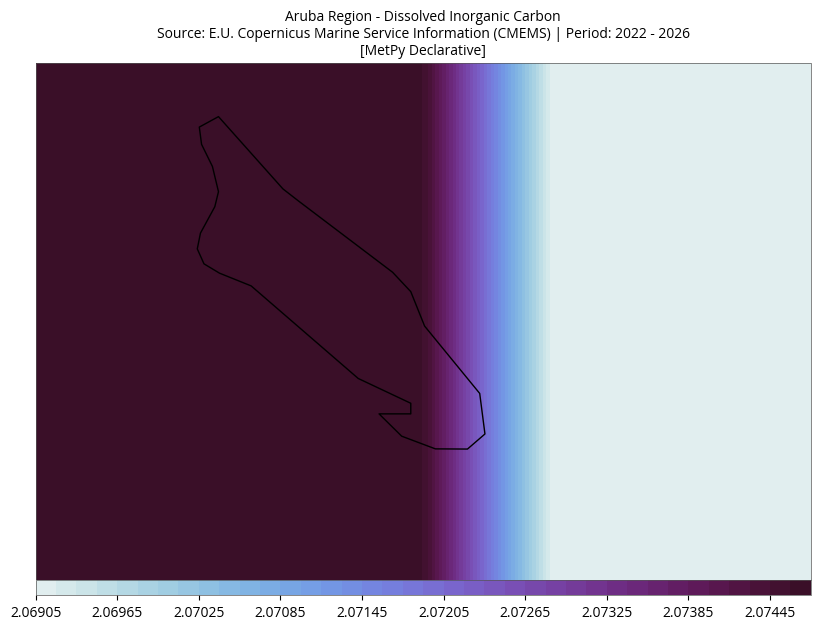

In [38]:
# Plot Dissolved Inorganic Carbon using MetPy Declarative
da = aruba_bgc_smooth.dissic if var_metadata['dissic']['is_bgc'] else aruba_phy_smooth.dissic
years = datasets['aruba_bgc_years'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['dissic']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'dissic' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'dissic' == 'speed' else None
plot_metpy(da, 'dissic', var_metadata['dissic'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


## Variable: Total Alkalinity (talk) - Aruba Region


### Cartopy Standalone Plot: Total Alkalinity (Aruba)


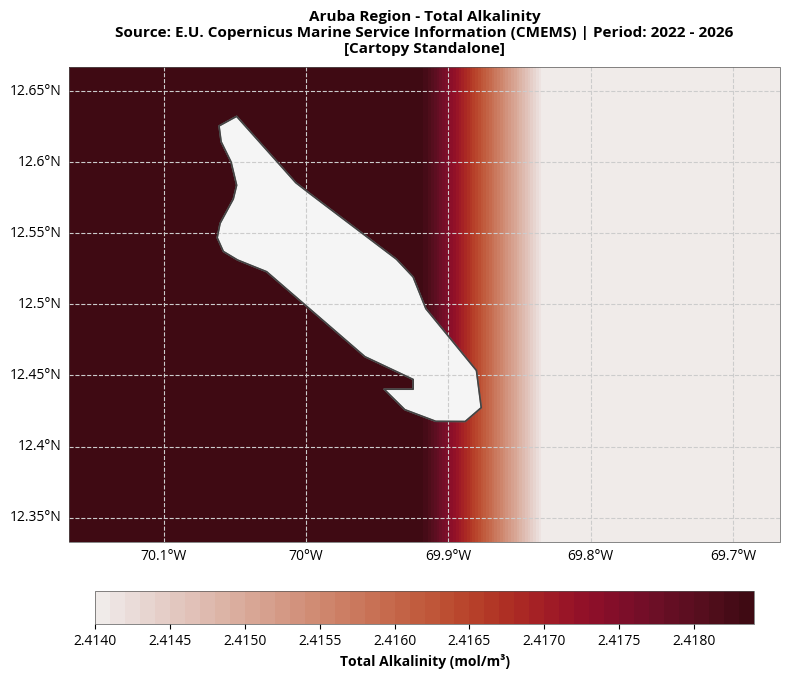

In [39]:
# Plot Total Alkalinity using Cartopy Standalone
da = aruba_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else aruba_phy_smooth.talk
years = datasets['aruba_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'talk' == 'speed' else None
plot_cartopy(da, 'talk', var_metadata['talk'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### earthkit-maps Plot: Total Alkalinity (Aruba)


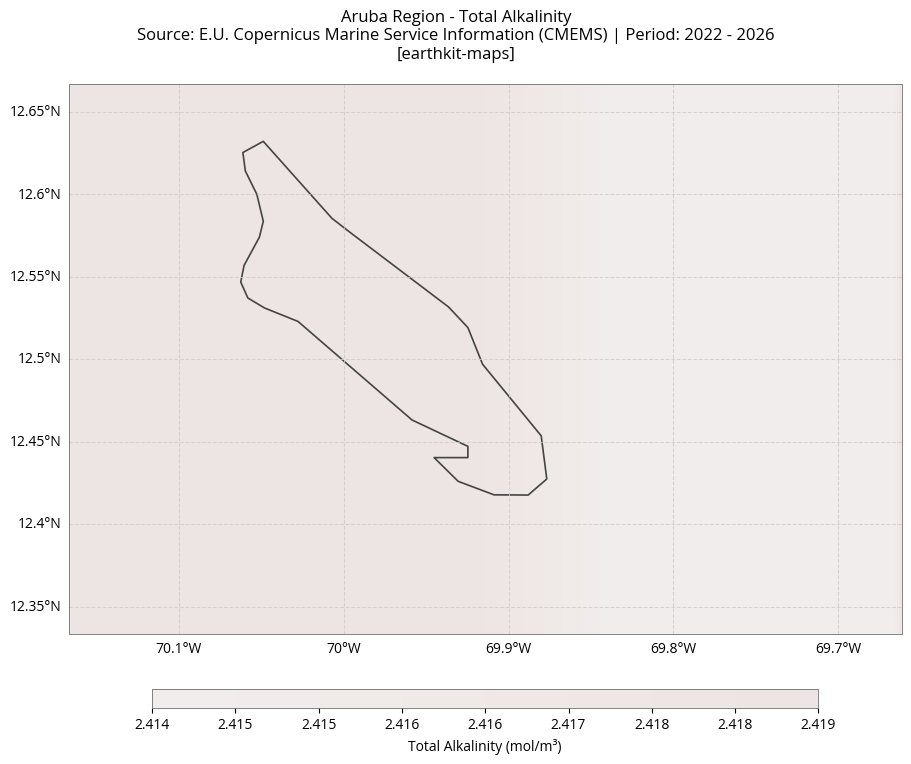

In [40]:
# Plot Total Alkalinity using earthkit-maps
da = aruba_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else aruba_phy_smooth.talk
years = datasets['aruba_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'talk' == 'speed' else None
plot_earthkit(da, 'talk', var_metadata['talk'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


### MetPy Declarative Plot: Total Alkalinity (Aruba)


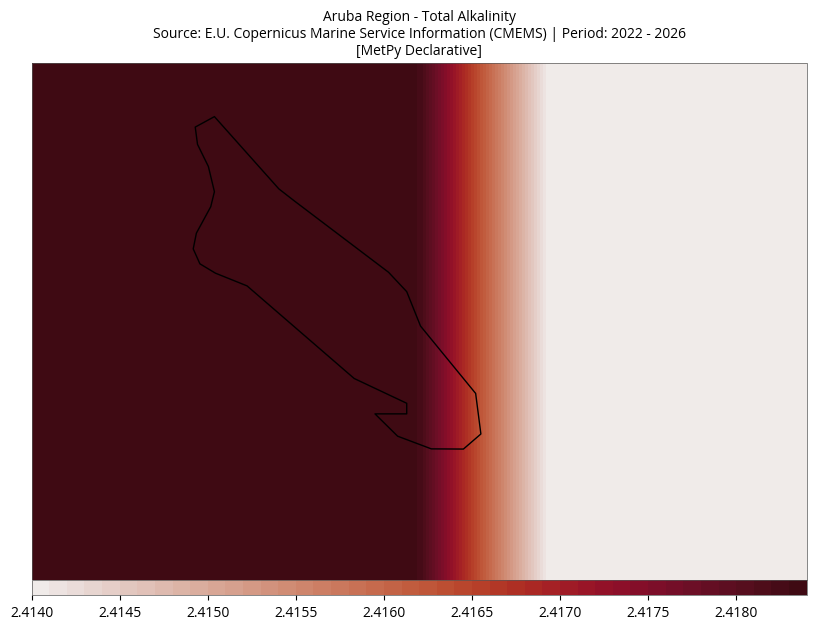

: 

In [ ]:
# Plot Total Alkalinity using MetPy Declarative
da = aruba_bgc_smooth.talk if var_metadata['talk']['is_bgc'] else aruba_phy_smooth.talk
years = datasets['aruba_bgc_years'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_years']
source = datasets['aruba_bgc_source'] if var_metadata['talk']['is_bgc'] else datasets['aruba_phy_source']
uo_da = aruba_phy_smooth.uo if 'talk' == 'speed' else None
vo_da = aruba_phy_smooth.vo if 'talk' == 'speed' else None
plot_metpy(da, 'talk', var_metadata['talk'], 'Aruba Region', years, source, uo=uo_da, vo=vo_da)


# Summary Matrix: Spatial Mapping Toolkits Comparison

| Evaluation Metric | Cartopy (Standalone) | earthkit-maps | MetPy Declarative |
| :--- | :--- | :--- | :--- |
| **Code Verbosity** | High (Requires manual setup of figure, axes, gridlines, extent, features, and colorbars) | Low (Very concise, single-line method calls for coastlines, land, title, legend) | Moderate (Structured class-based panel and plot declarations) |
| **Data Format Handling** | Manual (User must extract coordinates and pass arrays explicitly to plotting methods) | Native (Recognizes `xarray` and GRIB structures automatically) | Native (Requires standard coordinate names, dimension definitions, and Pint-compatible unit attributes) |
| **Custom Flexibility** | Infinite (Exposes full matplotlib API directly, allowing arbitrary overlays, styling, and modifications) | High (Provides direct Matplotlib axes control if needed via standard kwargs, but abstracts defaults) | Moderate (Locked into preset synoptic layouts; highly optimized for atmospheric science representations) |
| **Projection Logic** | Manual (Must pass `transform` and `projection` explicitly to axes and plot methods) | Automatic (Detects native coordinates or allows direct selection via naming/extent) | Standardized (Configured via `MapPanel.projection` and bounds in `MapPanel.area` properties) |
| **Best Suited For** | Complex multi-panel plots, highly customized layouts, and specialized visualizations. | Quick, high-quality meteorological/climatological mapping of ECMWF grids. | Standard synoptic weather maps, sounding analyses, and standard atmospheric plotting workflows. |
